# Hierarchical forecasting II with `numpyro_forecast`

This notebook ports the blog post [**Hierarchical forecasting with
NumPyro (part
II)**](https://juanitorduz.github.io/numpyro_hierarchical_forecasting_2/)
to the
[`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast)
package. This example is by itelf a port of the second part of the
original Pyro example: [**Forecasting III: hierarchical
models**](https://pyro.ai/examples/forecasting_iii.html). Where [part
I](hierarchical_forecasting_1.html) fixed a single destination, here we
model the **full `50x50` origin-destination panel** at once. Rides flow
between station pairs with clear asymmetries, so we let the local-level
dynamic be driven by the destination, build the seasonal effect and the
noise scale from both an origin and a destination part, and add a static
**pairwise** term for the affinity of each origin-destination pair.

> **Note on reproducibility.** We match the blog’s data, seed, optimizer
> and step counts. Results reproduce the blog’s behavior and CRPS
> magnitude but are not bit-for-bit identical: the forecast horizon uses
> the package’s separate-`_future`-site mechanism rather than re-running
> the guide over the full covariates. Because the full panel is large,
> predictive draws are done in memory-bounded batches.

## Prepare notebook

In [1]:
from typing import cast

import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import xarray as xr
from jax import random
from jax.tree_util import tree_map
from numpyro.infer import Predictive
from numpyro.infer.reparam import LocScaleReparam
from numpyro.optim import Adam

from numpyro_forecast import Forecaster, ForecastingModel, eval_crps
from numpyro_forecast.datasets import load_bart_hierarchical
from numpyro_forecast.typing import Array
from numpyro_forecast.util import periodic_repeat

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Read data

We load the full windowed origin-destination panel (`log1p` counts, `90`
training days plus `2` test weeks) in the package convention
`(origin, time, destin)`, with time at axis `-2`. This is the same
dataset as part I, but now we keep every destination instead of slicing
one out.

data shape: (50, 2496, 50) | split: 2160

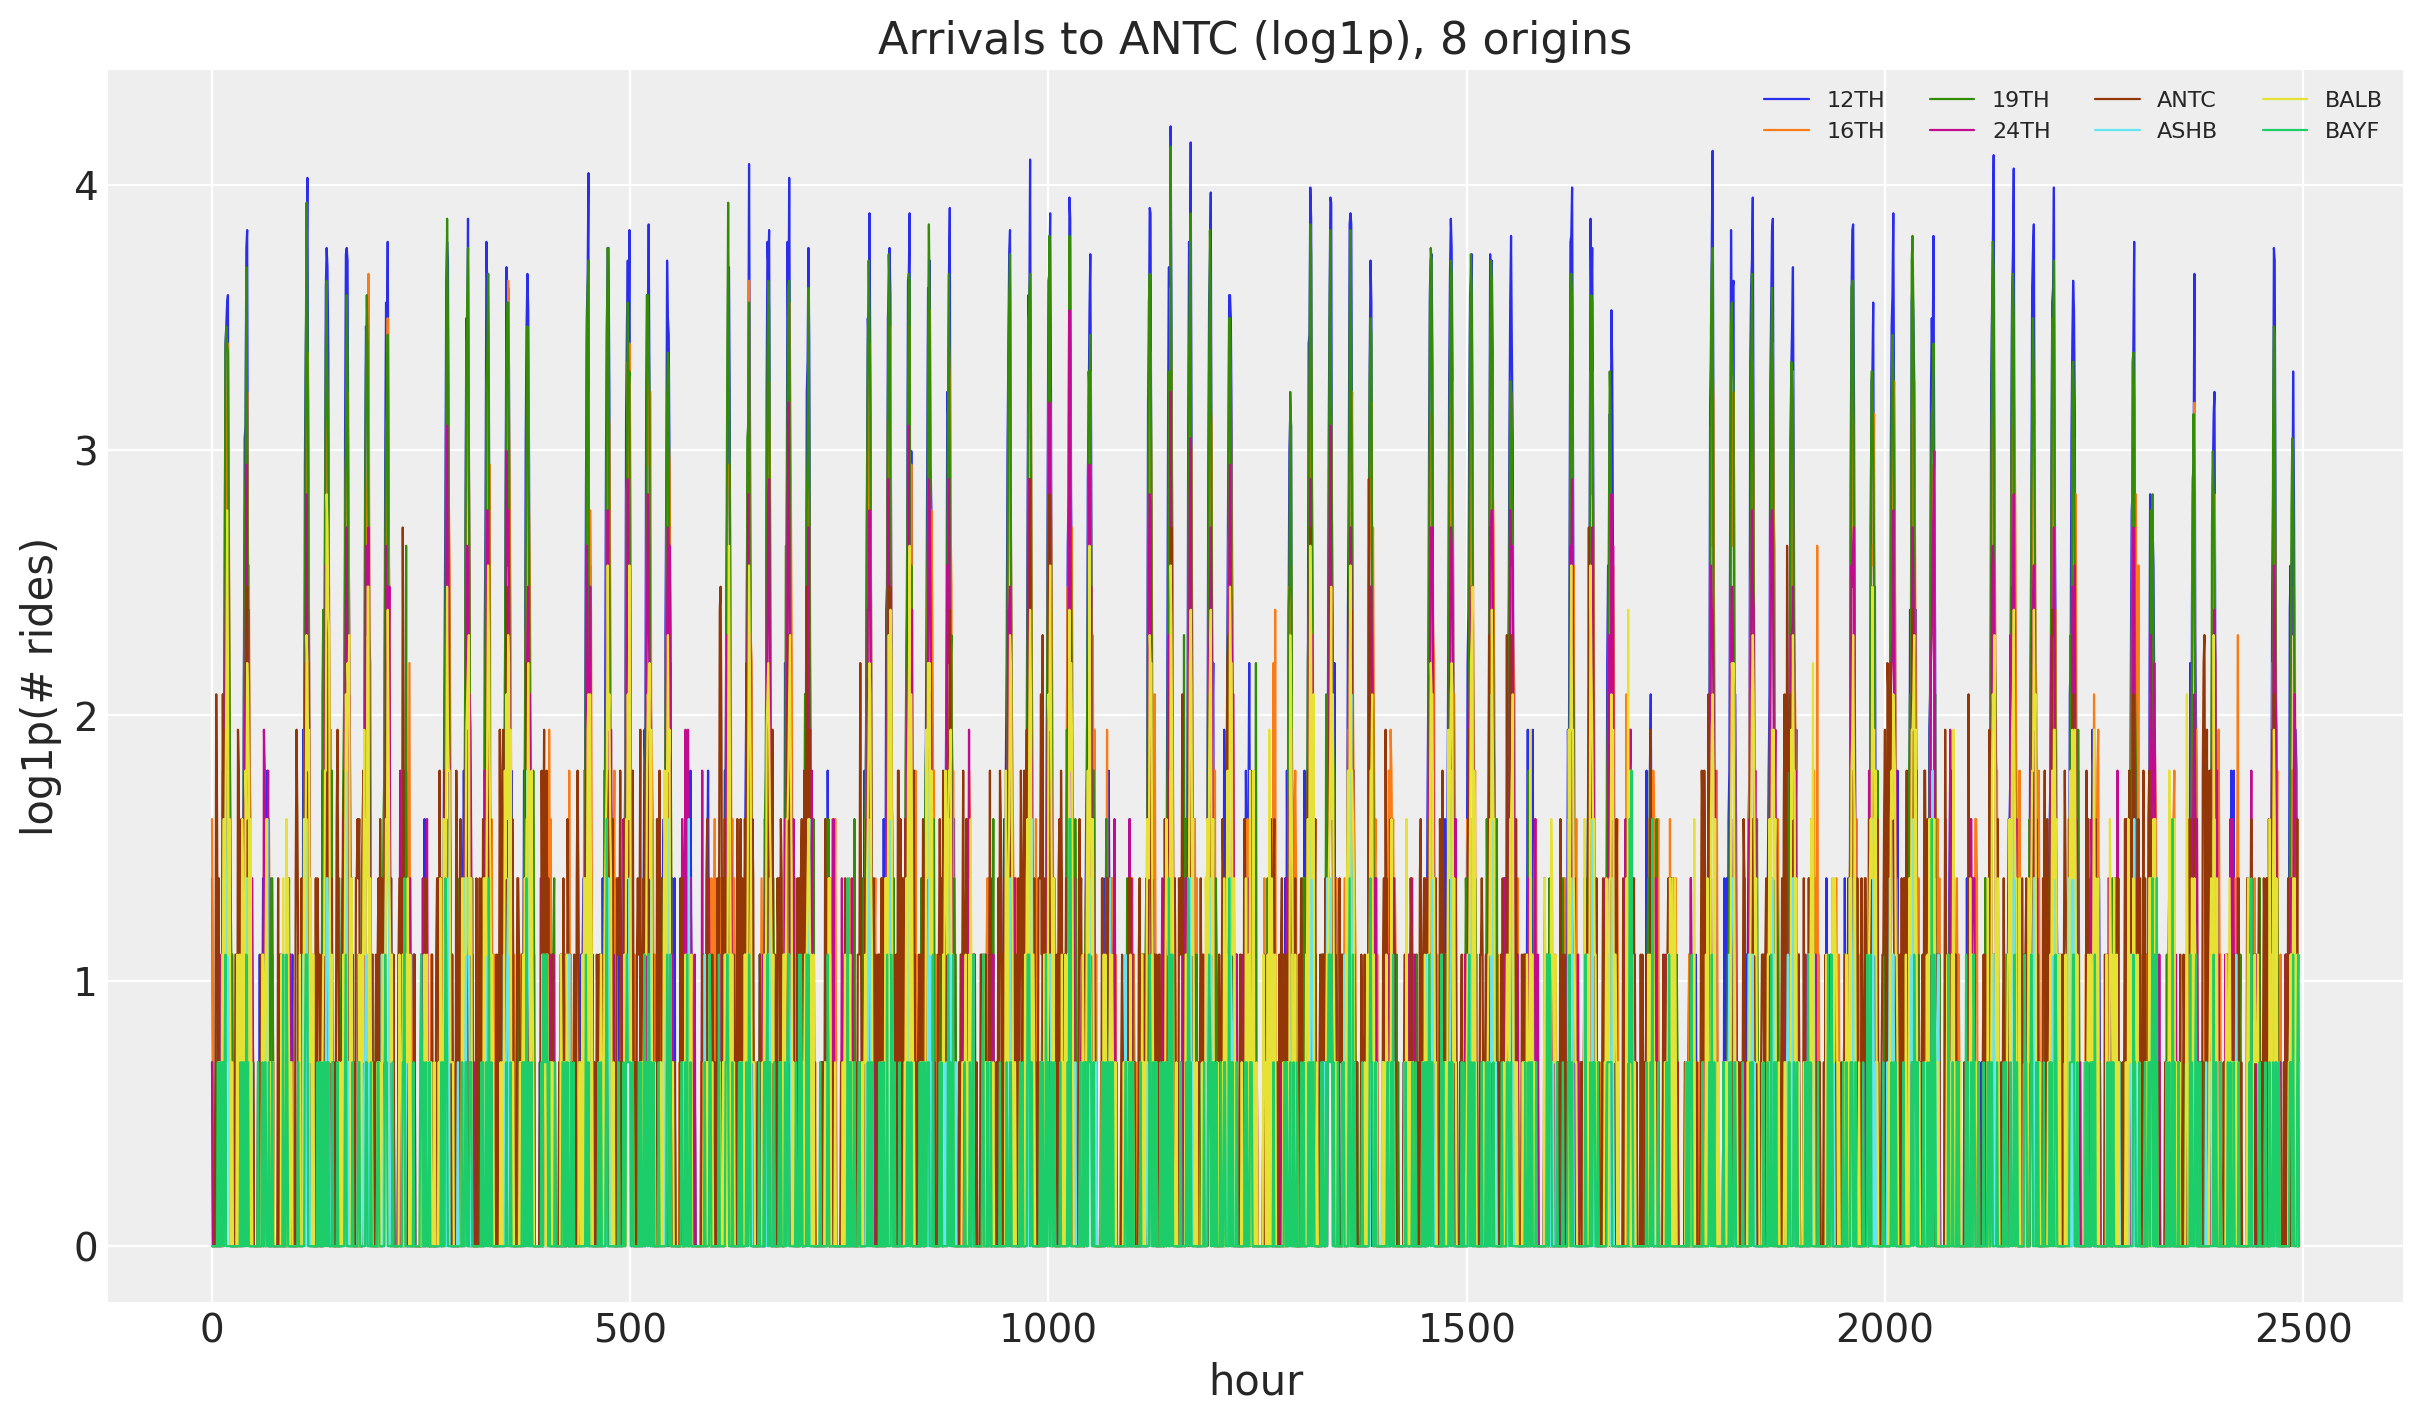

In [2]:
y, split, stations = load_bart_hierarchical()
n_origin, _, n_destin = y.shape
print("data shape:", y.shape, "| split:", split)

antc = stations.index("ANTC")
fig, ax = plt.subplots()
for i in range(8):
    ax.plot(np.asarray(y[i, :, antc]), lw=0.8, label=stations[i])
ax.legend(ncol=4, fontsize=8)
ax.set(title="Arrivals to ANTC (log1p), 8 origins", xlabel="hour", ylabel="log1p(# rides)");

## Train-test split

As before, the last two weeks (`336` hours) are held out for testing.
The covariates are dummy zeros over the whole panel: only their shape is
read, to separate the in-sample window from the forecast horizon.

In [3]:
T0 = 0
T1 = split  # 2_160
T2 = y.shape[1]  # 2_496

y_train = y[:, T0:T1, :]
y_test = y[:, T1:T2, :]
covariates = jnp.zeros((n_origin, T2, n_destin))
covariates_train = covariates[:, T0:T1, :]

time = np.arange(T2)
time_train = time[T0:T1]
time_test = time[T1:T2]
print("train:", y_train.shape, "test:", y_test.shape)

# Christmas anomaly index (BART series starts 2011-01-01, hourly).
dates = pd.date_range("2011-01-01", periods=78_888, freq="h")[-T2:]
christmas = np.flatnonzero((dates.month == 12) & (dates.day == 25))
christmas_index = int(christmas[0]) if len(christmas) else None
print("christmas index:", christmas_index)

train: (50, 2160, 50) test: (50, 336, 50)
christmas index: 2328

## Model specification

The structure mirrors part I but spreads the effects across two
hierarchies, origin and destination, plus the hour-of-week. The
random-walk `level` is indexed by destination: it captures how busy an
arrival station is over time. The seasonal effect and the observation
scale are each a **sum** of an origin part and a destination part, so a
ride inherits the weekly rhythm and the noisiness of both its endpoints.
On top of that, a static **pairwise** term models the affinity of each
origin-destination pair, which absorbs structure the additive parts miss
(for instance, people rarely travel from a station back to itself).

We declare three plates, `origin` (dim `-3`), `hour_of_week` (dim `-2`)
and `destin` (dim `-1`), and open each effect under the plates it
depends on. The per-destination level is sampled with
`self.time_series(...)` under the `destin` plate, and the seasonal
effect is tiled across the full horizon with `periodic_repeat`.
Broadcasting over the three plate dimensions assembles the
`(origin, time, destin)` mean.

In [4]:
class HierarchicalForecaster(ForecastingModel):
    """Hierarchical OD model with per-station seasonality, drift and pairwise term."""

    def __init__(self, period: int = 24 * 7) -> None:
        super().__init__()
        self.period = period

    def model(self, zero_data: Array | None, covariates: Array) -> None:
        """Define the hierarchical forecasting model."""
        n_origin = covariates.shape[-3]
        n_destin = covariates.shape[-1]
        duration = covariates.shape[-2]

        origin_plate = numpyro.plate("origin", n_origin, dim=-3)
        destin_plate = numpyro.plate("destin", n_destin, dim=-1)
        hour_plate = numpyro.plate("hour_of_week", self.period, dim=-2)

        drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-20.0, 5.0))
        destin_centered = numpyro.sample("destin_centered", dist.Uniform(0.0, 1.0))

        with origin_plate, hour_plate:
            origin_seasonal = numpyro.sample("origin_seasonal", dist.Normal(0.0, 5.0))
        with hour_plate, destin_plate:
            destin_seasonal = numpyro.sample("destin_seasonal", dist.Normal(0.0, 5.0))

        with destin_plate:
            drift = self.time_series(
                "drift",
                lambda: dist.Normal(0.0, drift_scale),
                reparam=LocScaleReparam(centered=destin_centered),
            )
        level = jnp.cumsum(drift, axis=-2)

        with origin_plate, destin_plate:
            pairwise = numpyro.sample("pairwise", dist.Normal(0.0, 1.0))

        with origin_plate:
            origin_scale = numpyro.sample("origin_scale", dist.LogNormal(-5.0, 5.0))
        with destin_plate:
            destin_scale = numpyro.sample("destin_scale", dist.LogNormal(-5.0, 5.0))
        scale = origin_scale + destin_scale

        seasonal = cast("Array", origin_seasonal + destin_seasonal)
        seasonal_repeat = periodic_repeat(seasonal, duration, axis=-2)
        prediction = level + seasonal_repeat + pairwise

        self.predict(dist.Normal(0.0, scale), prediction)

Let’s visialize the model:

In [5]:
period = 24 * 7  # weekly seasonality (hours)

numpyro.render_model(
    HierarchicalForecaster(period=period),
    model_args=(covariates_train, y_train),
    render_distributions=True,
)

## Prior predictive checks

As usual (highly recommended!), we run prior predictive checks. The full
panel is large, so we draw the samples in memory-bounded batches with
the `batched_obs` helper and keep only what we plot (eight origins
arriving at `ANTC`, last three training weeks). The prior ranges look
reasonable, if anything a touch too wide.

prior band shape: (500, 8, 504)

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_36442/741911304.py:98: UserWarning: The figure layout has changed to tight
  fig.tight_layout();

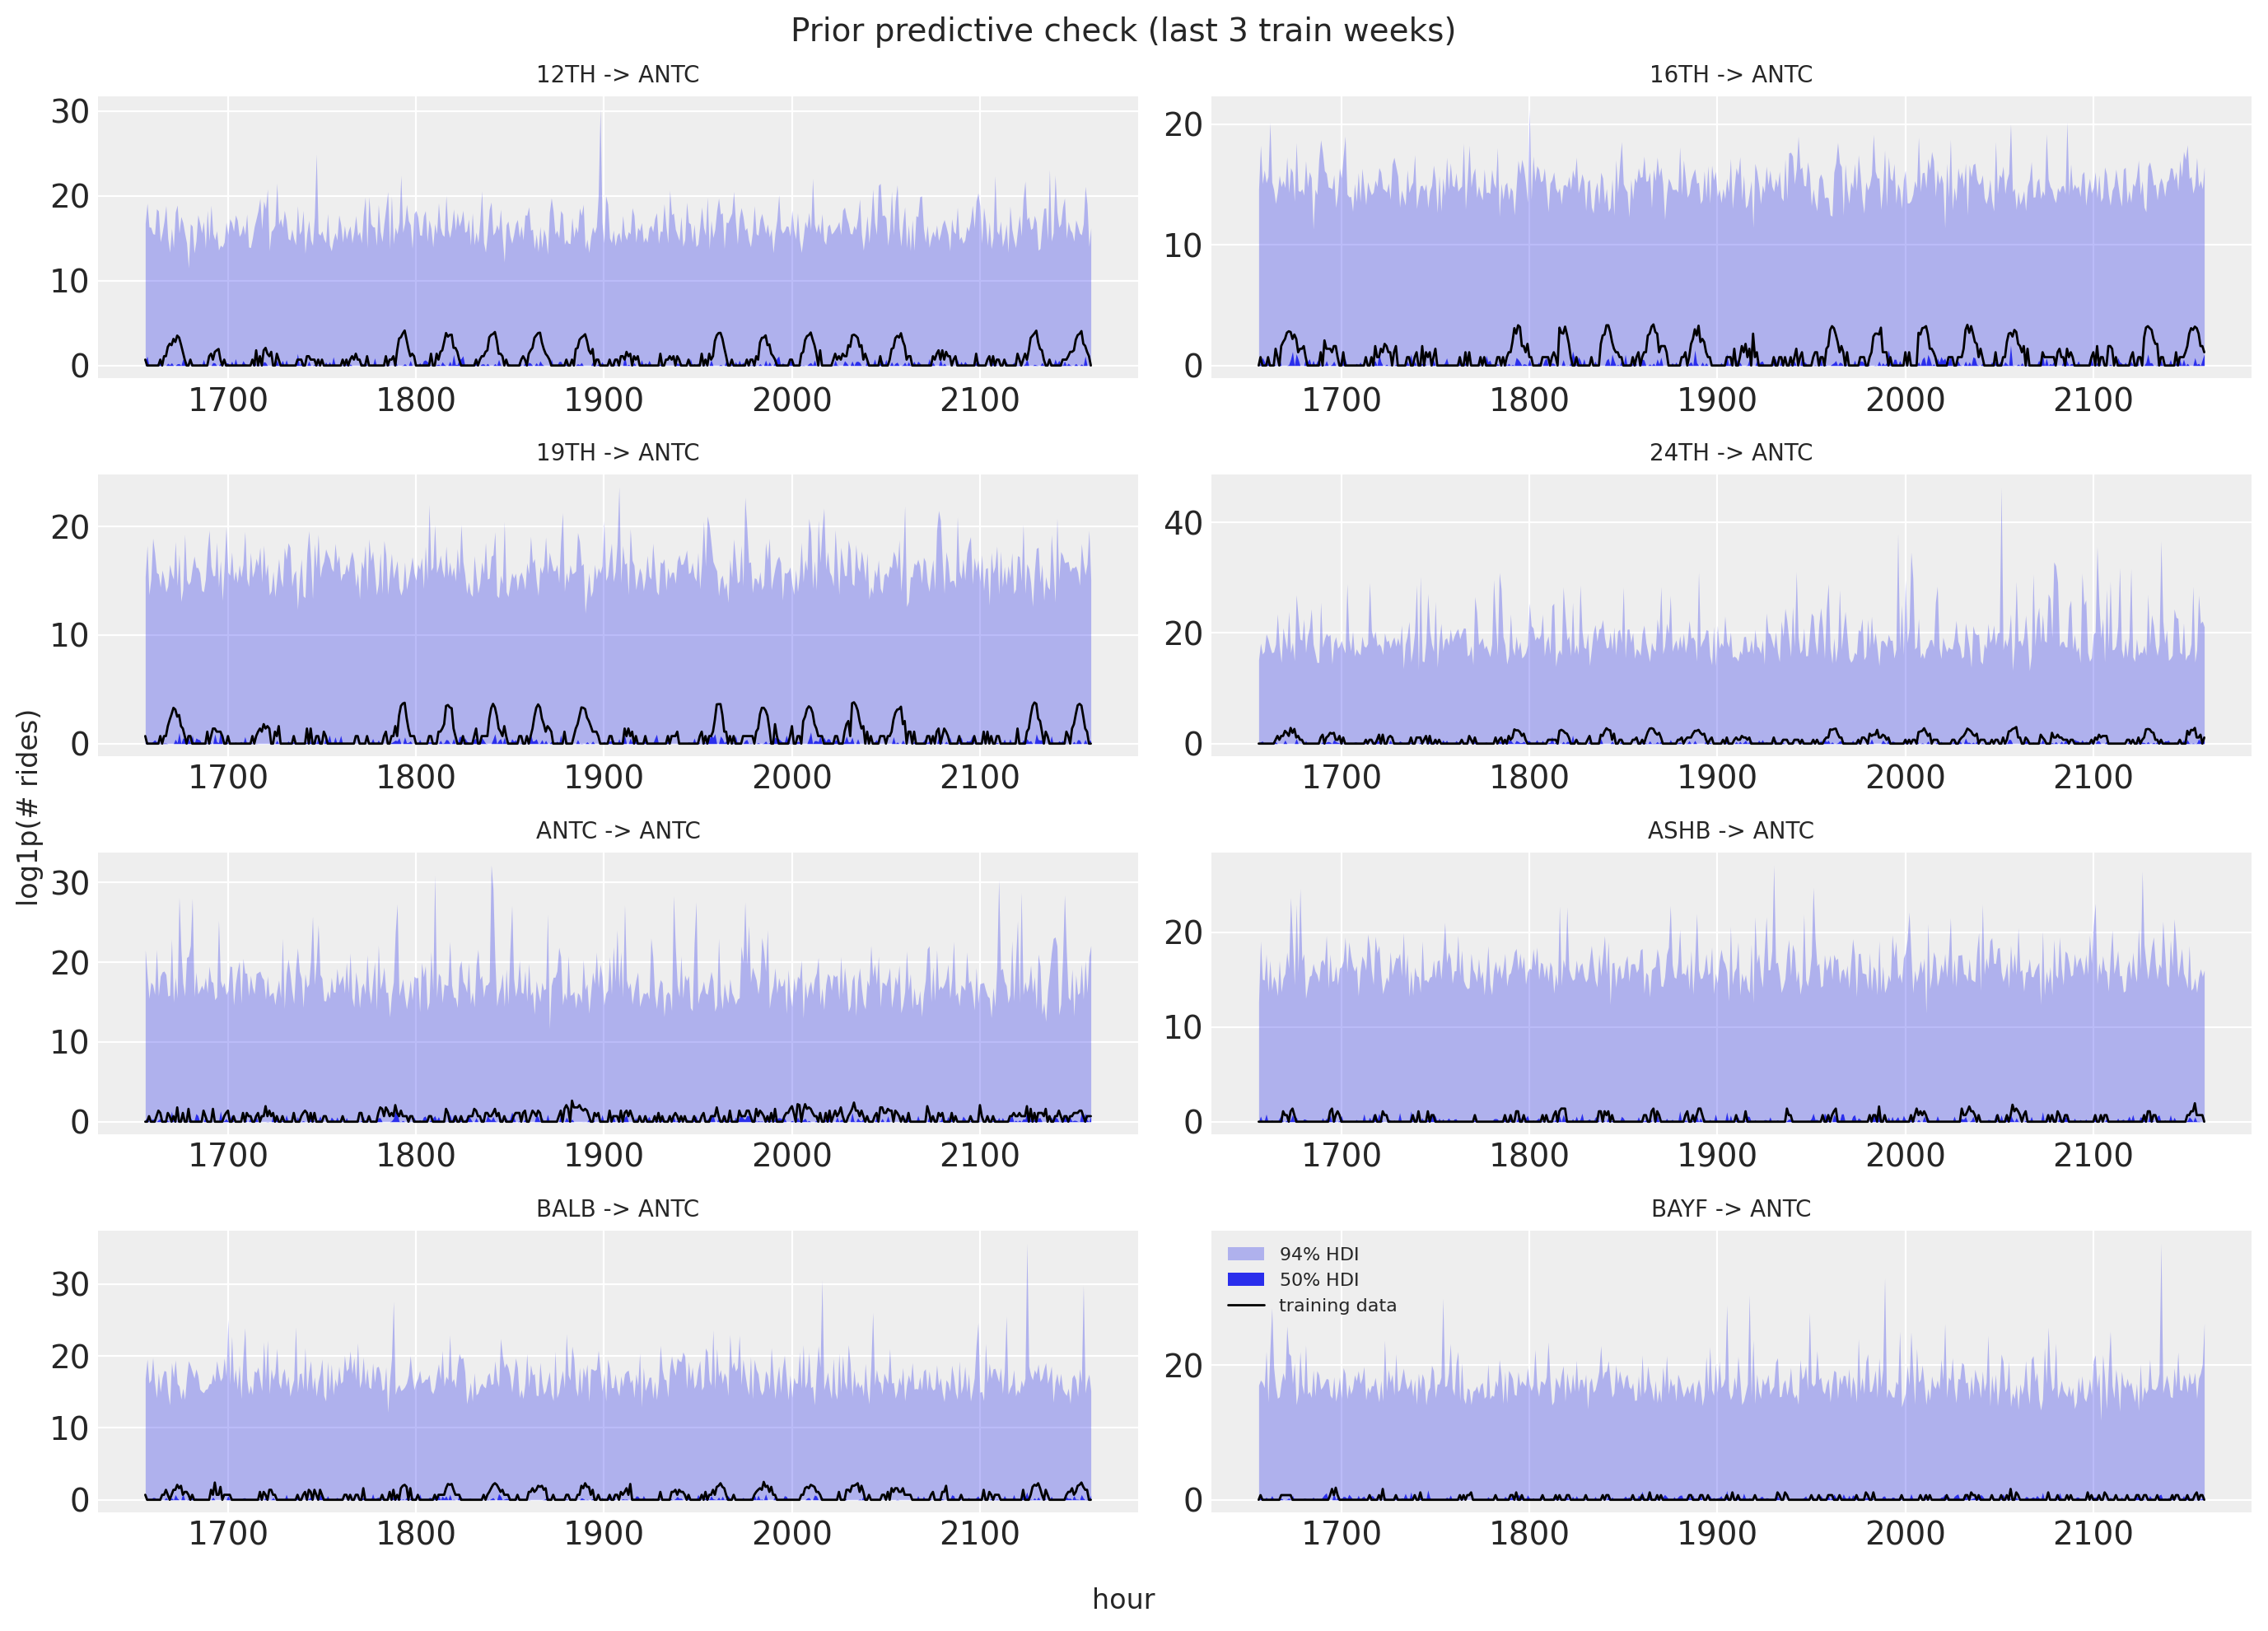

In [6]:
n_plot = 8  # origins shown in the facet grid
dest = "ANTC"
series = list(range(n_plot))


def faceted_idata(
    obs: Array | np.ndarray, t: Array | np.ndarray, group: str = "posterior_predictive"
) -> xr.DataTree:
    """Pack ``(draws, time, series)`` predictions into a DataTree for `plot_lm` faceting.

    The independent variable in ``constant_data`` carries the ``series`` dimension so that
    `plot_lm` facets one panel per series (`plot_dim="time"`).
    """
    t = np.asarray(t, dtype=float)
    x_grid = np.broadcast_to(t[:, None], (len(t), n_plot))
    return az.from_dict(
        {
            group: {"obs": np.asarray(obs)[None]},
            "observed_data": {"obs": np.zeros((len(t), n_plot))},
            "constant_data": {"t": x_grid},
        },
        coords={"time": t, "series": series},
        dims={"obs": ["time", "series"], "t": ["time", "series"]},
    )


def batched_obs(make_pred, key, covariates, num_samples, batch_size, select=None):
    chunks = []
    for start in range(0, num_samples, batch_size):
        n = min(batch_size, num_samples - start)
        key, sub = random.split(key)
        obs = make_pred(start, n)(sub, covariates)["obs"]
        chunks.append(np.asarray(obs if select is None else select(obs)))
    return np.concatenate(chunks, axis=0)


model = HierarchicalForecaster(period=period)
lo = T1 - 3 * period  # last three train weeks

rng_key, rng_subkey = random.split(rng_key)
prior_band = batched_obs(
    lambda start, n: Predictive(model, num_samples=n, return_sites=["obs"]),
    rng_subkey,
    covariates_train,
    num_samples=500,
    batch_size=100,
    select=lambda o: o[:, :n_plot, lo:T1, antc],
)
print("prior band shape:", prior_band.shape)

# Predictions arrive as (draws, origin, time); move time before the series facet dim.
t_train = time_train[lo:T1].astype(float)
prior_obs = np.transpose(prior_band.clip(min=0), (0, 2, 1))  # (draws, time, series)

pc = az.plot_lm(
    faceted_idata(prior_obs, t_train, group="prior_predictive"),
    y="obs",
    x="t",
    plot_dim="time",
    group="prior_predictive",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    col_wrap=2,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    },
    figure_kwargs={"figsize": (14, 10)},
)
truth_da = xr.DataArray(
    np.asarray(y_train[:n_plot, lo:T1, antc]).T,
    dims=["time", "series"],
    coords={"time": t_train, "series": series},
    name="t",
)
x_da = xr.DataArray(t_train, dims=["time"], coords={"time": t_train})
pc.map(
    az.visuals.line_xy, "truth", data=truth_da, x=x_da, ignore_aes=pc.aes_set, color="black", lw=1
)
for i in series:
    pc.get_target("t", {"series": i}).set_title(f"{stations[i]} -> {dest}", fontsize=10)
ax0 = pc.get_target("t", {"series": n_plot - 1})
bands = pc.viz["ci_band"]["t"].sel(series=n_plot - 1)
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(r"$94\%$ HDI")
band_50.set_label(r"$50\%$ HDI")
train_line = pc.viz["truth"]["t"].sel(series=n_plot - 1).item()
train_line.set_label("training data")
ax0.legend(handles=[band_94, band_50, train_line], loc="upper left", fontsize=8)
fig = pc.viz["figure"].item()
fig.supxlabel("hour")
fig.supylabel("log1p(# rides)")
fig.suptitle("Prior predictive check (last 3 train weeks)", fontsize=14)
fig.tight_layout();

## Inference with SVI

We fit the model with SVI through `Forecaster` (an `AutoNormal` guide
with `Adam`). The panel is much larger than in part I, so this step
takes a few minutes; the ELBO on a log scale should still settle into a
clear plateau.

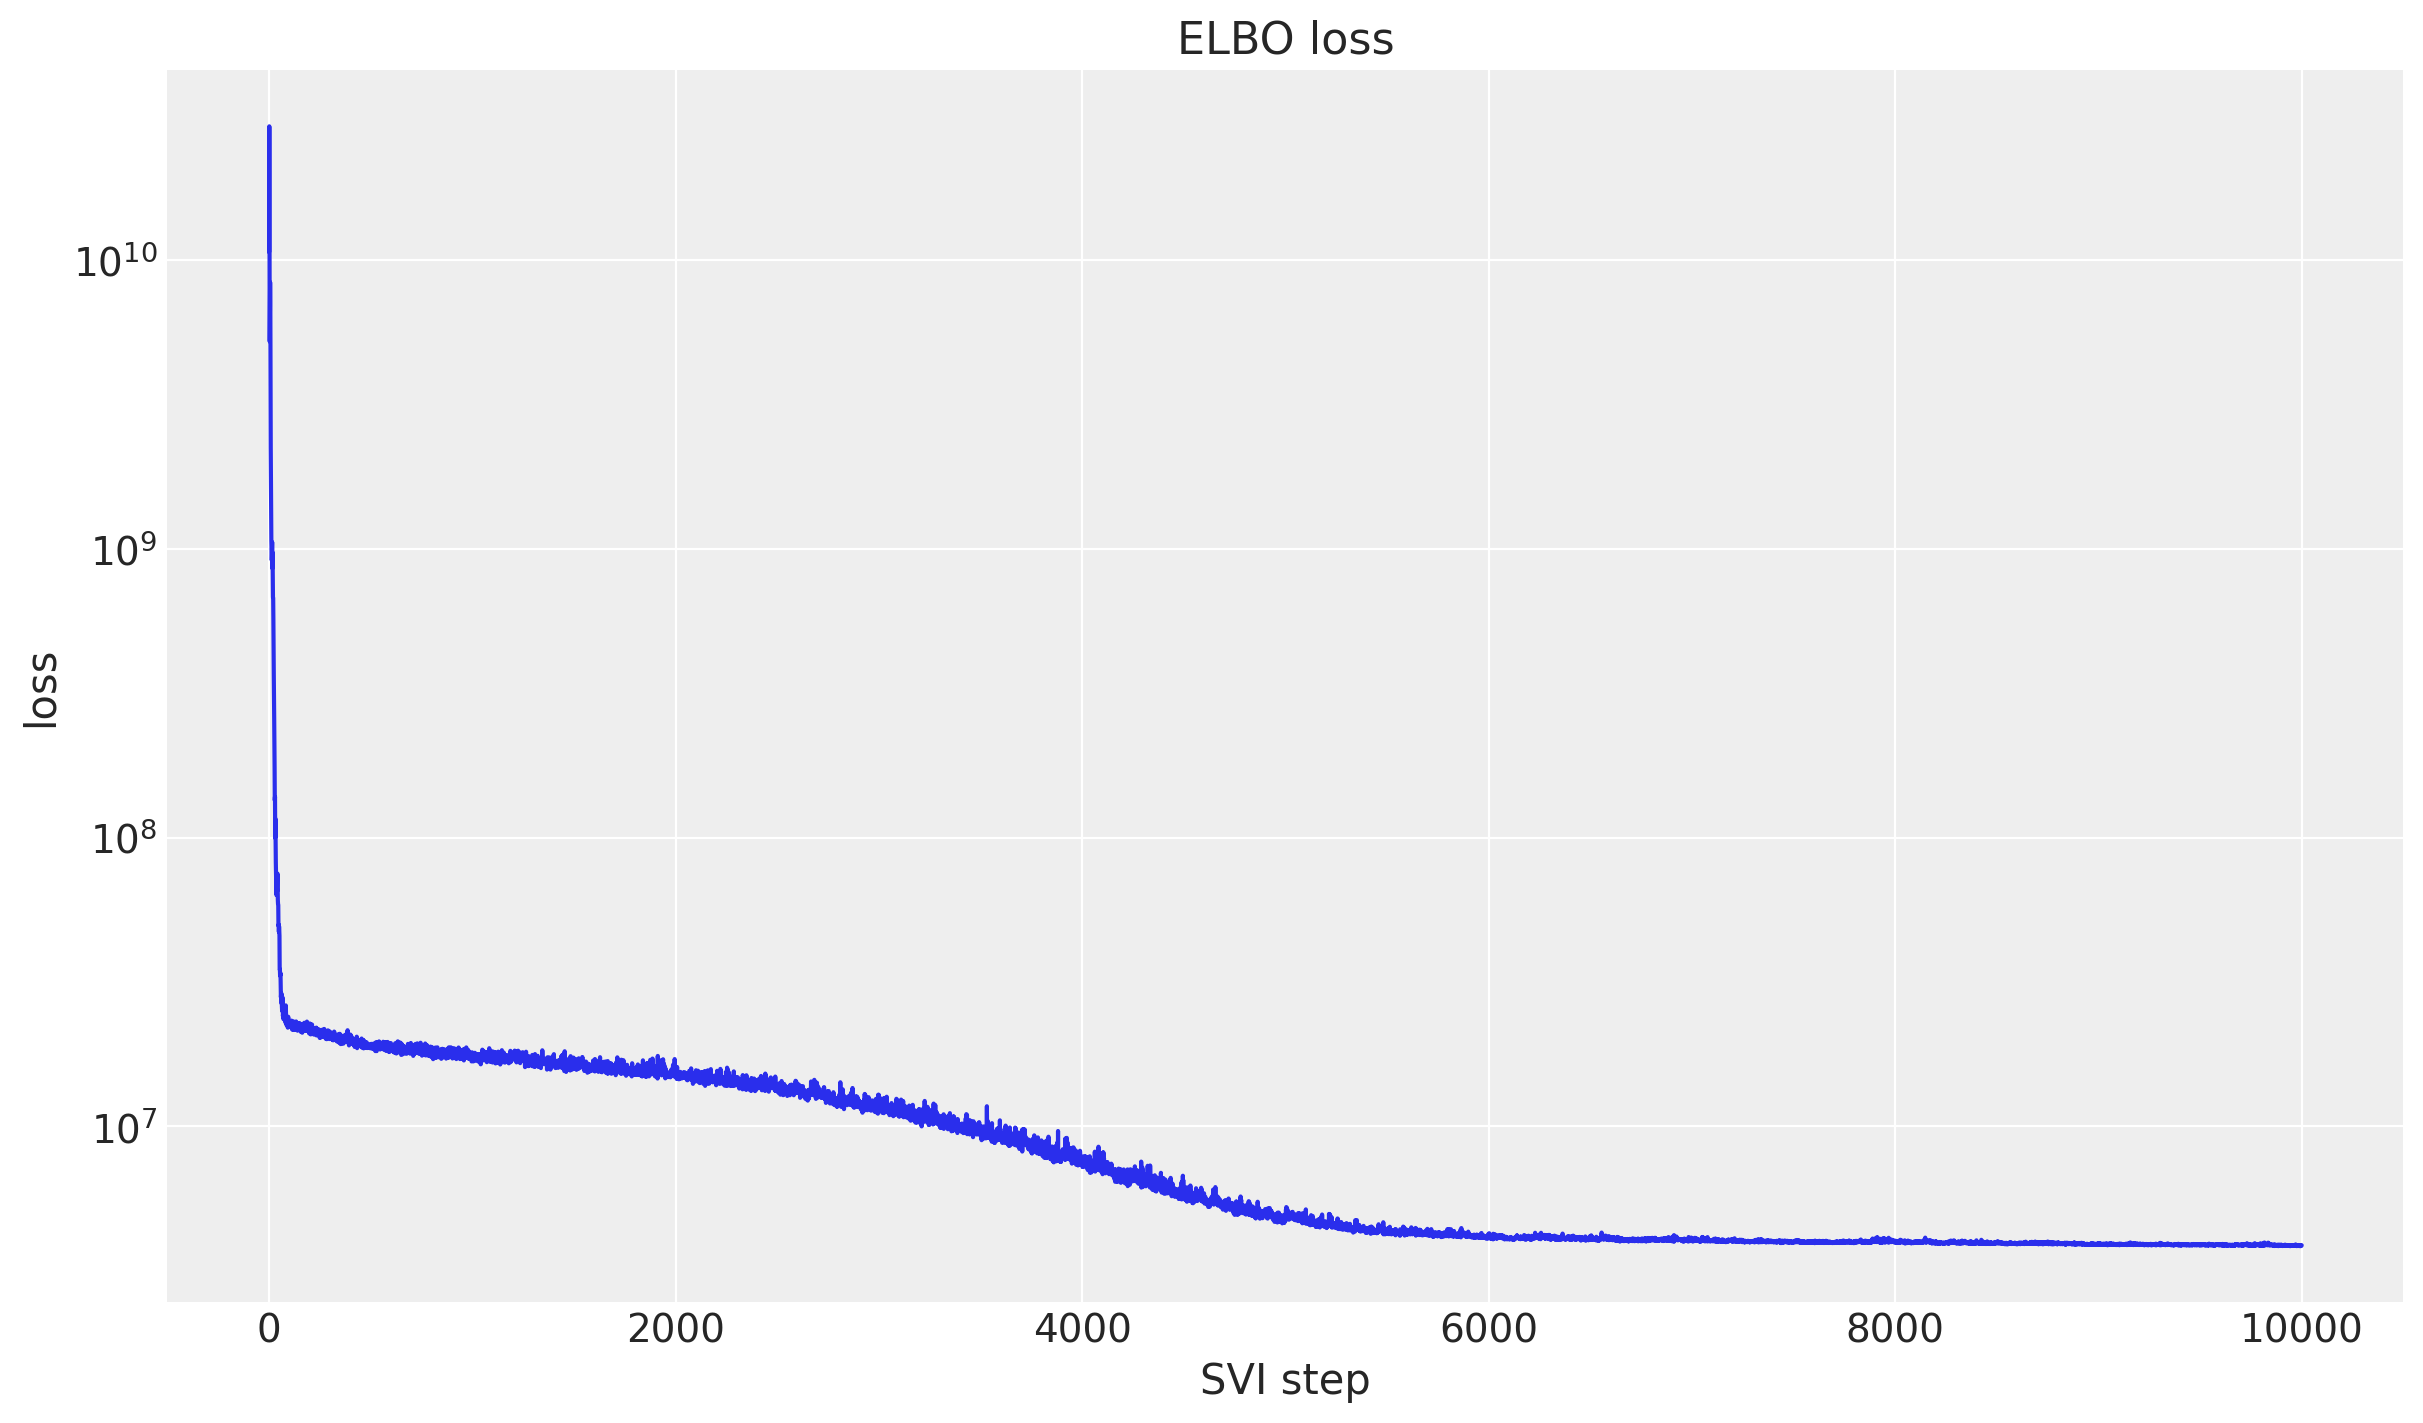

In [7]:
rng_key, rng_subkey = random.split(rng_key)
forecaster = Forecaster(
    rng_subkey,
    model,
    y_train,
    covariates_train,
    optim=Adam(step_size=0.1),
    num_steps=10_000,
)

fig, ax = plt.subplots()
ax.plot(forecaster.losses)
ax.set_yscale("log")
ax.set(title="ELBO loss", xlabel="SVI step", ylabel="loss");

## Posterior predictive check

We draw the in-sample posterior predictive and the forecast, both in
memory-bounded batches: the in-sample draws through `batched_obs`, the
forecast through `Forecaster`’s own `batch_size` argument. The
full-panel train CRPS is accumulated one origin at a time so the
intermediate arrays never blow up host memory. As before, predictions
are clipped at zero (the `log1p` scale is non-negative) before scoring.

In [8]:
rng_key, key_post, key_pp, key_fc = random.split(rng_key, 4)
num_post = 200

posterior_samples = forecaster.guide.sample_posterior(
    key_post, forecaster.params, sample_shape=(num_post,)
)
train_pp = batched_obs(
    lambda start, n: Predictive(
        model,
        posterior_samples=tree_map(lambda x: x[start : start + n], posterior_samples),
        return_sites=["obs"],
    ),
    key_pp,
    covariates_train,
    num_samples=num_post,
    batch_size=50,
)  # (num_post, origin, train, destin) on host

forecast = forecaster(key_fc, y_train, covariates, num_samples=num_post, batch_size=50)
forecast = jnp.clip(forecast, min=0.0)

# Full-panel train CRPS, accumulated per origin to bound memory.
train_crps_per_origin = [
    eval_crps(jnp.clip(jnp.asarray(train_pp[:, i]), min=0.0), y_train[i]) for i in range(n_origin)
]
crps_train = float(np.mean(train_crps_per_origin))
crps_test = eval_crps(forecast, y_test)
print(f"Train CRPS: {crps_train:.4f}")
print(f"Test CRPS:  {crps_test:.4f}")

Train CRPS: 0.2388
Test CRPS:  0.2806

## Forecast visualization

Eight origins arriving at `ANTC`: the in-sample posterior predictive
(blue, last three train weeks) and the forecast (orange) with 50% and
94% HDI bands, against the observed series, with the train/test split
and the Christmas day band marked. With origin, destination and pairwise
effects in play, the full panel is fit jointly, yet each individual
origin-to-destination forecast still tracks its own weekly pattern. As
in part I, Christmas is the visible soft spot, since the model has no
holiday feature.

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_36442/2085423411.py:106: UserWarning: The figure layout has changed to tight
  fig.tight_layout();

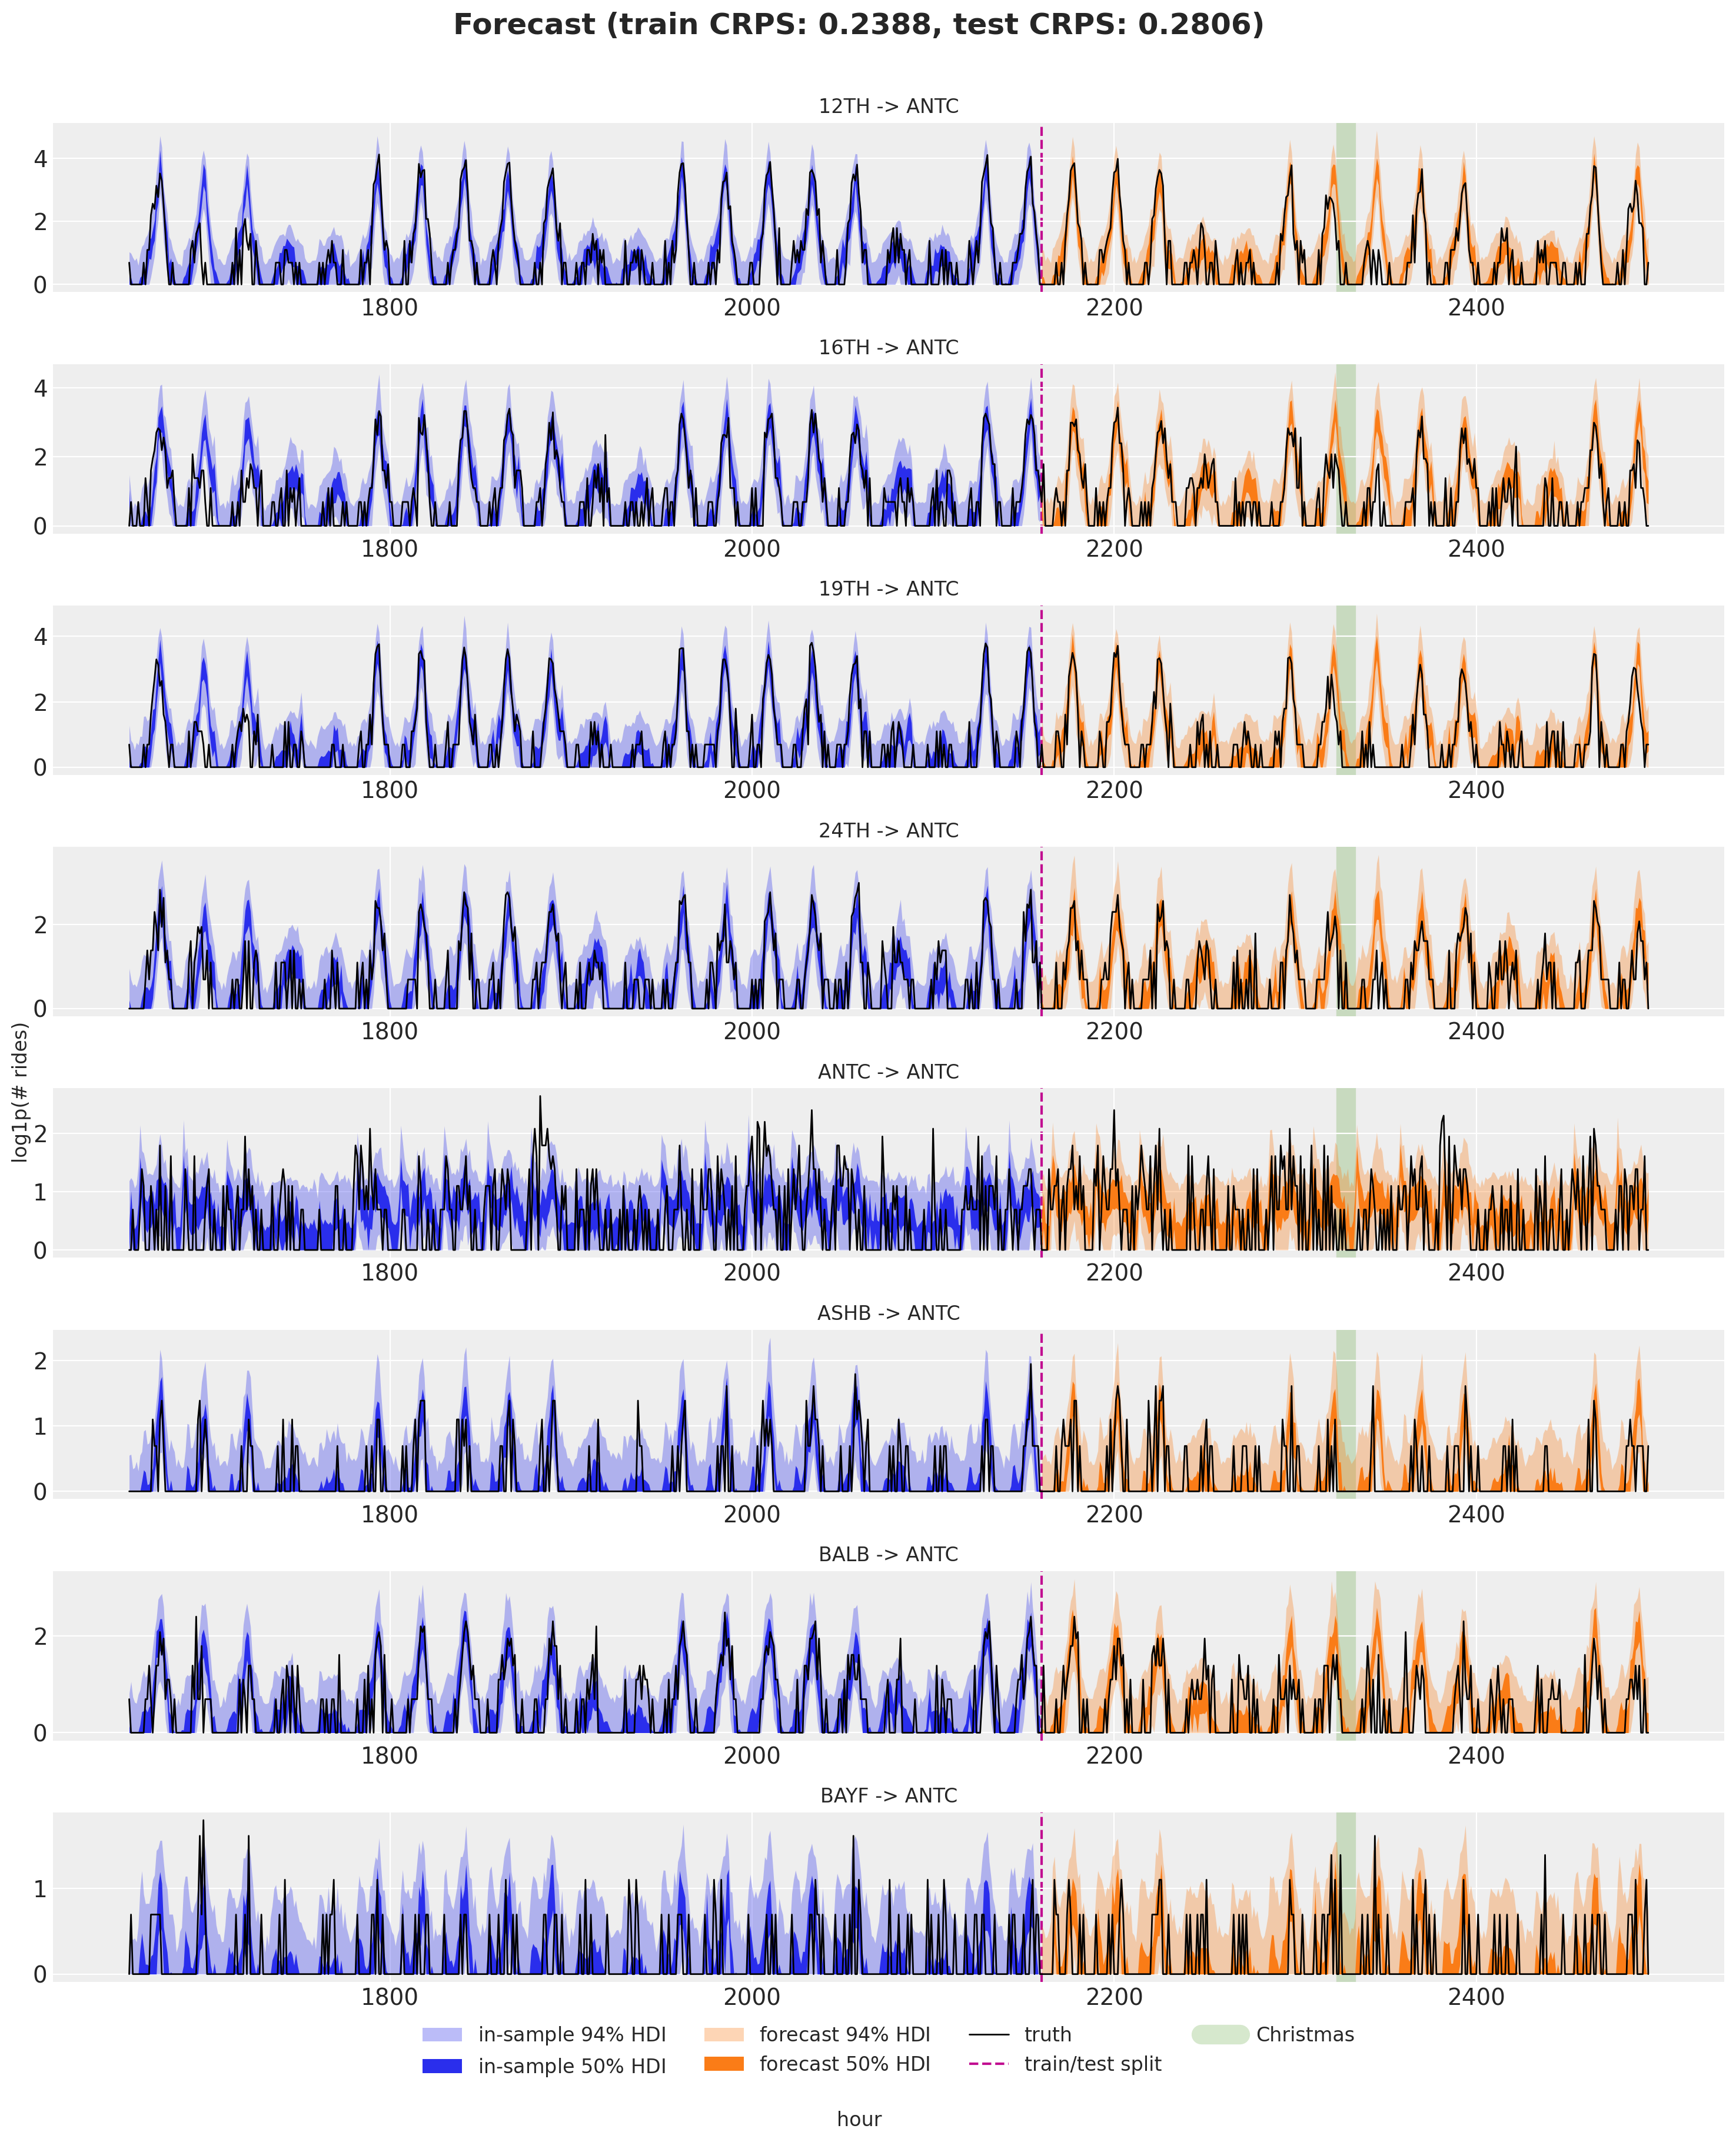

In [9]:
# Predictions arrive as (draws, origin, time); move time before the series facet dim.
train_plot = np.transpose(np.clip(train_pp[:, :n_plot, lo:T1, antc], 0, None), (0, 2, 1))
forecast_plot = np.transpose(np.asarray(forecast[:, :n_plot, :, antc]), (0, 2, 1))

t_train = time_train[lo:T1].astype(float)
t_test = time_test.astype(float)
t_full = time[lo:T2].astype(float)

pc = az.plot_lm(
    faceted_idata(train_plot, t_train),
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    col_wrap=1,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    },
    figure_kwargs={"figsize": (15, 18)},
)
train_bands = pc.viz["ci_band"]["t"].sel(series=n_plot - 1)
band_train_94 = train_bands.sel(prob=0.94).item()
band_train_50 = train_bands.sel(prob=0.5).item()
az.plot_lm(
    faceted_idata(forecast_plot, t_test),
    y="obs",
    x="t",
    plot_dim="time",
    plot_collection=pc,
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={
        "ci_band": {"color": "C1"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    },
)

# Observed series and the split / Christmas markers on every facet, each in one call.
truth_da = xr.DataArray(
    np.asarray(y[:n_plot, lo:T2, antc]).T,
    dims=["time", "series"],
    coords={"time": t_full, "series": series},
    name="t",
)
x_da = xr.DataArray(t_full, dims=["time"], coords={"time": t_full})
pc.map(
    az.visuals.line_xy, "truth", data=truth_da, x=x_da, ignore_aes=pc.aes_set, color="black", lw=1
)
split_da = xr.DataArray(
    np.full(n_plot, float(T1)), dims=["series"], coords={"series": series}, name="t"
)
pc.map(az.visuals.vline, "split", data=split_da, ignore_aes=pc.aes_set, color="C3", ls="--")
if christmas_index is not None:
    xmas_da = xr.DataArray(
        np.full(n_plot, float(christmas_index)),
        dims=["series"],
        coords={"series": series},
        name="t",
    )
    pc.map(
        az.visuals.vline, "xmas", data=xmas_da, ignore_aes=pc.aes_set, color="C2", lw=12, alpha=0.2
    )

for i in series:
    pc.get_target("t", {"series": i}).set_title(f"{stations[i]} -> {dest}", fontsize=12)

# Build the legend once, on the first facet, from the real band and line artists.
ax0 = pc.get_target("t", {"series": n_plot - 1})
test_bands = pc.viz["ci_band"]["t"].sel(series=n_plot - 1)
band_test_94 = test_bands.sel(prob=0.94).item()
band_test_50 = test_bands.sel(prob=0.5).item()
band_train_94.set_label(r"in-sample $94\%$ HDI")
band_train_50.set_label(r"in-sample $50\%$ HDI")
band_test_94.set_label(r"forecast $94\%$ HDI")
band_test_50.set_label(r"forecast $50\%$ HDI")
truth_line = pc.viz["truth"]["t"].sel(series=n_plot - 1).item()
split_line = pc.viz["split"]["t"].sel(series=n_plot - 1).item()
truth_line.set_label("truth")
split_line.set_label("train/test split")
handles = [band_train_94, band_train_50, band_test_94, band_test_50, truth_line, split_line]
if christmas_index is not None:
    xmas_line = pc.viz["xmas"]["t"].sel(series=n_plot - 1).item()
    xmas_line.set_label("Christmas")
    handles.append(xmas_line)

fig = pc.viz["figure"].item()
fig.supxlabel("hour")
fig.supylabel("log1p(# rides)")
ax0.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncols=4, fontsize=12)
fig.suptitle(
    f"Forecast (train CRPS: {crps_train:.4f}, test CRPS: {crps_test:.4f})",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)
fig.tight_layout();

## Next steps

This closes the three-part tour: a single series in the [univariate
notebook](forecasting_univariate.html), one destination in [part
I](hierarchical_forecasting_1.html), and the full origin-destination
panel here. The same holiday caveat applies (special dates like
Christmas still need explicit features), and richer pairwise or low-rank
structure is a natural extension. For the original treatment, see Pyro’s
[hierarchical forecasting
tutorial](https://pyro.ai/examples/forecasting_iii.html).

## References

- Orduz, J. [*Hierarchical forecasting with NumPyro (part
  II)*](https://juanitorduz.github.io/numpyro_hierarchical_forecasting_2/).
- Pyro. [*Forecasting III: Hierarchical
  Models*](https://pyro.ai/examples/forecasting_iii.html).